In [1]:
#!/usr/bin/env python
# -*-coding:utf-8 -*-
'''
@File    :   real_data_analysis_1.ipynb
@Time    :   2024/09/06 12:01:19
@Author  :   Menetrier Baptiste 
@Version :   1.0
@Contact :   baptiste.menetrier@ecole-navale.fr
@Desc    :   None
'''

# ======================================================================================================================
# Import
# ======================================================================================================================
# %matplotlib ipympl

import sys 
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import os 
import pandas as pd
import numpy as np

import scipy.fft as sf
import scipy.signal as sp
import matplotlib.pyplot as plt

from get_data.ais.ais_tools import *
from real_data_analysis.signal_processing_utils import *
from real_data_analysis.real_data_utils import *
from publication.publication_figure import PubFigure
from localisation.verlinden.misc.verlinden_utils import load_rhumrum_obs_pos

PubFigure(label_fontsize=22, title_fontsize=24, legend_fontsize=16, ticks_fontsize=20)

In [2]:
# Def frequency properties
nperseg = 2**13
noverlap = int(nperseg * 3 / 4)

fmin = 4
fmax = 46
filter_type = "bandpass"
filter_corners = 4

freq_properties = {"fmin": fmin, "fmax": fmax, "filter_type": filter_type, "filter_corners": filter_corners, "noverlap": noverlap, "nperseg": nperseg}

In [3]:
# We are only interested in the hydrophone channel
ch = ["BDH"]
rcv_id = "RR48"
duration_seconds = 2 * 60 * 60 
date = "2013-05-09 13:30:00"
duration_s = 60 * 60 * 1.6

# Load data
data = load_wav_data(date=date, rcv_id=rcv_id, duration_s=duration_s, ch=ch, freq_properties=freq_properties)

# Define dsp parameters
dsp_args = {
    "nperseg": nperseg,
    "overlap_coef": 3 / 4,
    "window": "hann",
    "fs": data["sig"].meta.sampling_rate,
    "fmin": fmin,
    "fmax": fmax
}

# Derive dsp
get_dsp(data, dsp_args=dsp_args)

In [4]:
# Plot stft
save= True
plot_stft(data, save=save)

In [5]:
# Plot dsp
fmin_plot = 4
fmax_plot = 18
plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot,save=save)

fmin_plot = 18
fmax_plot = 42
plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot, save=save)


In [6]:
# Select one ray
idx_ray = 5
ray_bandwith = 4
fmin_plot = data["f_peaks"][idx_ray] - ray_bandwith / 2
fmax_plot = data["f_peaks"][idx_ray] + ray_bandwith / 2

plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot, save=save)

## Plot spectrums for interesting days for all stations 

In [7]:
def process_plot(data, fmin, fmax, nperseg, save):
    # Define dsp parameters
    dsp_args = {
        "nperseg": nperseg,
        "overlap_coef": 3 / 4,
        "window": "hann",
        "fs": data["sig"].meta.sampling_rate,
        "fmin": fmin,
        "fmax": fmax,
    }

    # Derive dsp
    get_dsp(data, dsp_args=dsp_args)

    # Plot stft
    plot_stft(data, save=save)

    # Plot dsp
    fmin_plot = 4
    fmax_plot = 18
    plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot, save=save)

    fmin_plot = 18
    fmax_plot = 42
    plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot, save=save)

    # Select one ray
    idx_ray = np.argmax(data["Pxx_in_band"][data["idx_f_peaks"]])   # Most energetic ray
    # idx_ray = 5
    ray_bandwith = 4
    fmin_plot = data["f_peaks"][idx_ray] - ray_bandwith / 2
    fmax_plot = data["f_peaks"][idx_ray] + ray_bandwith / 2

    plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot, save=save)

    plt.close("all")

In [8]:
ch = ["BDH"]
rcv_id = "RR48"
duration_seconds = 2 * 60 * 60
date = "2013-05-09 13:30:00"
duration_s = 60 * 60 * 1.6

stations = ["RR41", "RR43", "RR44", "RR46", "RR47", "RR48"]
for rcv_id in stations:
    # Load data
    data = load_wav_data(
        date=date,
        rcv_id=rcv_id,
        duration_s=duration_s,
        ch=ch,
        freq_properties=freq_properties,
    )

    process_plot(data, fmin=fmin, fmax=fmax, nperseg=nperseg, save=True)

## 2H spectrograms to find interesting periods 

2013-04-01 00:00:00
2013-04-01 02:00:00


KeyboardInterrupt: 

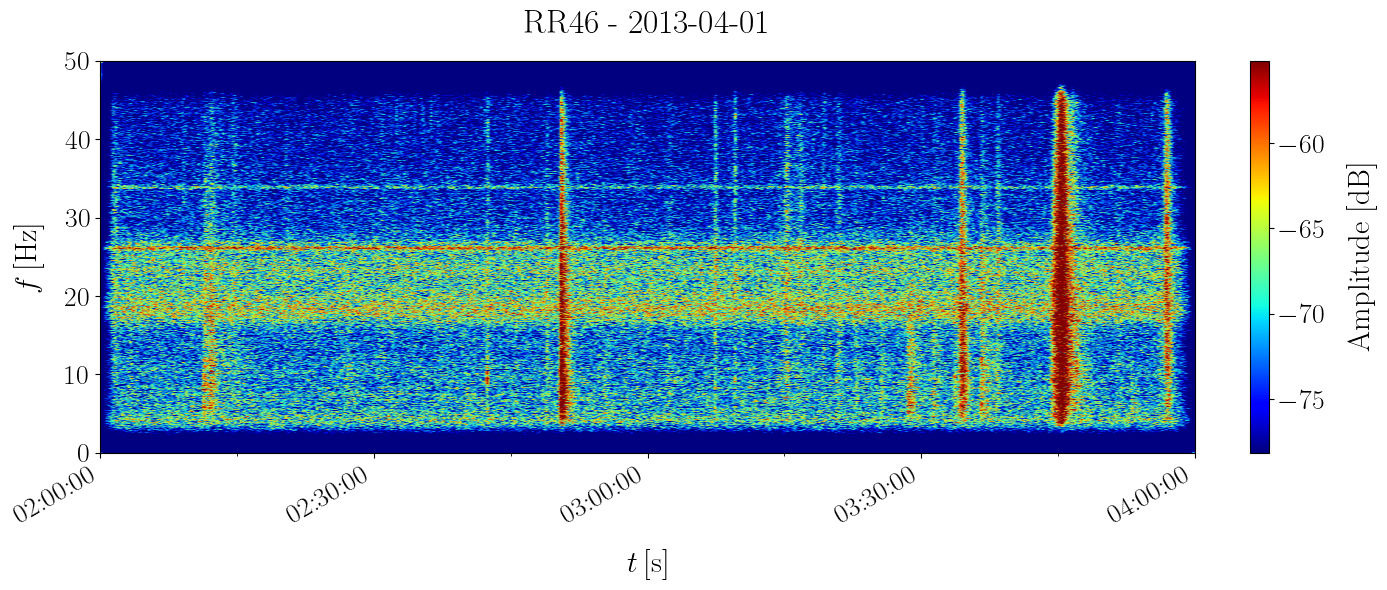

In [ ]:
ch = ["BDH"]
rcv_id = "RR46"
duration_seconds = 2 * 60 * 60
yyyy_mm = "2013-04"

save=True
freq_properties["nperseg"] = 2**12
freq_properties["noverlap"] = int(freq_properties["nperseg"] * 3/4)

for i_d in range(1, 32):
    for i_h in range(0, 12):
        date = f"{yyyy_mm}-{i_d:02d} {(i_h*2):02d}:00:00"
        print(date)
        data = load_wav_data(
            date=date,
            rcv_id=rcv_id,
            duration_s=duration_seconds,
            ch=ch,
            freq_properties=freq_properties,
        )

        # Plot stft
        plot_stft(data, save=save)

## Plot DSP for interesting periods found

In [ ]:
# Iceberg
rcv_id  = "RR43"
ch = ["BDH"]
date = "2013-05-31 12:33:00"
duration_seconds = 5 * 60 

nperseg = 2**10
freq_properties = {
    "fmin": fmin,
    "fmax": fmax,
    "filter_type": filter_type,
    "filter_corners": filter_corners,
    "noverlap": int(nperseg * 0.98),
    "nperseg": nperseg,
}

data = load_wav_data(
    date=date,
    rcv_id=rcv_id,
    duration_s=duration_seconds,
    ch=ch,
    freq_properties=freq_properties,
)

process_plot(data, fmin=fmin, fmax=fmax, nperseg=nperseg, save=True)

root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\wav\RHUMRUM"
fmt = "%Y-%m-%d_%H-%M-%S"
date_start = pd.to_datetime(date).strftime(fmt)
date_end = (pd.to_datetime(date) + pd.Timedelta(seconds=duration_seconds)).strftime(fmt)
fname = f"signal_{ch[0]}_{rcv_id}_{date_start}_{date_end}.wav"  
path= os.path.join(root, fname)
fs, wav = wavfile.read(path)
wavfile.write("test.wav", fs*50, wav)

In [ ]:
ch = ["BDH"]
duration_seconds = 2 * 60 * 60
date = "2013-05-09 13:30:00"
duration_s = 60 * 60 * 1.6

rcv_id = "RR46"
interesting_dates = [
    "2013-05-05 16:00:00",
    "2013-05-07 09:00:00",
    "2013-05-08 08:30:00",
    "2013-05-09 13:30:00",
    "2013-05-11 16:00:00",
    "2013-05-14 06:00:00",
    "2013-05-15 21:00:00",
    "2013-05-22 12:00:00",
    "2013-05-25 19:00:00",
]

KeyboardInterrupt: 

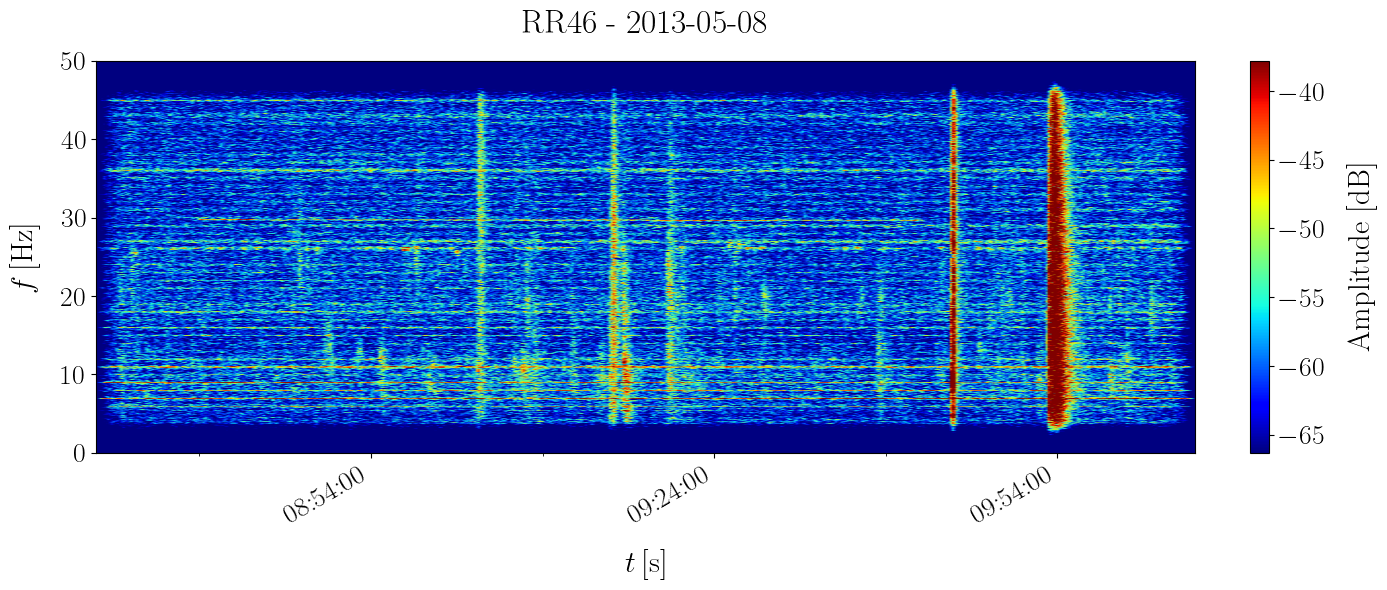

In [ ]:
for date in interesting_dates:
    # Load data
    data = load_wav_data(
        date=date,
        rcv_id=rcv_id,
        duration_s=duration_s,
        ch=ch,
        freq_properties=freq_properties,
    )

    process_plot(data, fmin=fmin, fmax=fmax, nperseg=nperseg, save=True)

In [ ]:

# Find mmsi from dates 
for date in interesting_dates:
    print(date)
    potential_mmsi, ais_mmsi = find_mmsi_from_date(date, duration_s)
    print(ais_mmsi)


2013-05-05 16:00:00
Empty DataFrame
Columns: [time, lon, lat, mmsi, shipName]
Index: []
2013-05-07 09:00:00
                  time        lon        lat       mmsi        shipName
0  2013-05-07 07:23:35  65.154945 -27.649978  353766000  STELLAR HERMES
1  2013-05-07 07:28:35  65.169286 -27.643946  353766000  STELLAR HERMES
2  2013-05-07 07:33:35  65.183626 -27.637913  353766000  STELLAR HERMES
3  2013-05-07 07:38:35  65.197965 -27.631878  353766000  STELLAR HERMES
4  2013-05-07 07:43:35  65.212302 -27.625842  353766000  STELLAR HERMES
5  2013-05-07 07:48:35  65.226637 -27.619804  353766000  STELLAR HERMES
6  2013-05-07 07:53:35  65.240971 -27.613765  353766000  STELLAR HERMES
7  2013-05-07 07:58:35  65.255303 -27.607724  353766000  STELLAR HERMES
8  2013-05-07 08:03:35  65.269634 -27.601682  353766000  STELLAR HERMES
9  2013-05-07 08:08:35  65.283963 -27.595638  353766000  STELLAR HERMES
10 2013-05-07 08:13:35  65.298290 -27.589593  353766000  STELLAR HERMES
11 2013-05-07 08:18:35  65.3

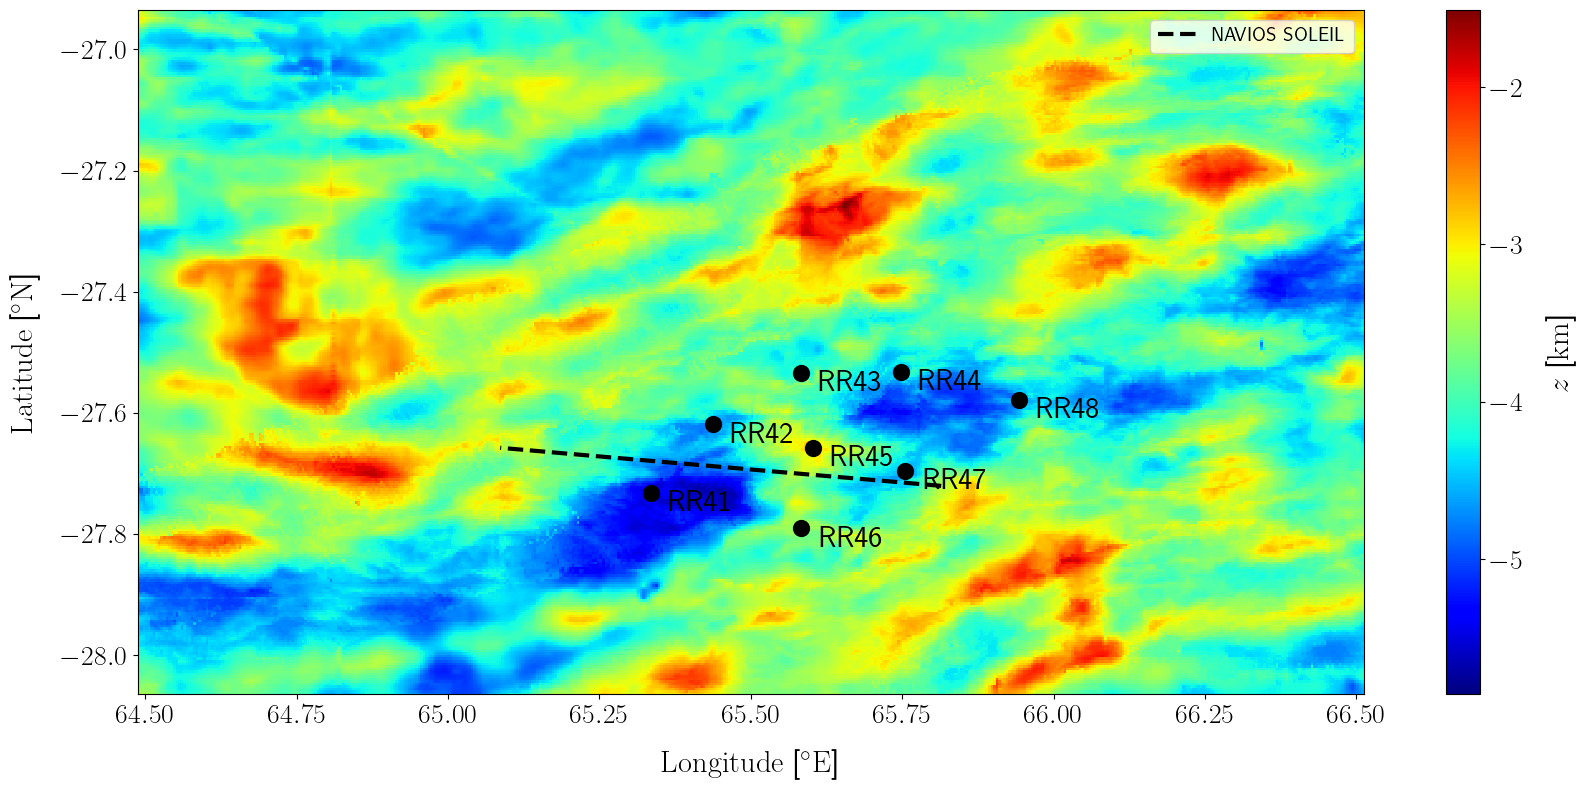

In [ ]:
# Plot trajectory of a given ship over the SWIR bathymétrie
lon_min = 65
lon_max = 66
lat_min = -28
lat_max = -27
date = "2013-05-09 13:30:00"
mmsi, ais_data = find_mmsi_from_date(date, duration_s)

station_id = ["RR46", "RR47", "RR48", "RR45", "RR44", "RR43", "RR41", "RR42"]

rcv_info = {"id": station_id, "lons": [], "lats": []}
for obs_id in rcv_info["id"]:
    pos_obs = load_rhumrum_obs_pos(obs_id)
    rcv_info["lons"].append(pos_obs.lon)
    rcv_info["lats"].append(pos_obs.lat)

plot_traj_over_bathy(ais_data, rcv_info, lon_min, lon_max, lat_min, lat_max)

In [ ]:
# Save ais data for selected trajectory
ais_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ais"
date_str = pd.to_datetime(date).strftime("%Y-%m-%d_%H-%M")
fname = f"ais_extracted_{date_str}_{mmsi[0]}.csv"
fpath = os.path.join(ais_root, fname)
ais_data.to_csv(fpath, index=False)